# PAYG Social Security in a 2-Period OLG Model

## Model overview

A simple 2-period OLG model with **exogenous labour supply** and a **PAYG pension system**.
Each agent lives two periods: young (works, saves, pays pension contributions)
and old (retires, consumes savings plus pension benefit).

**Preferences:**
$$U = \ln c_1 + \beta_0 \ln c_2 - \frac{\nu_0}{1+\nu_1}\ell^{1+\nu_1}$$

**Production:**  $Y = K^\alpha L^{1-\alpha}$

**PAYG pension:**  contributions from the young finance the pensions of the old in each period.

## Workflow

| Step | Description |
|---|---|
| 1 | Parameters |
| 2 | No-pension steady state ($\tau=0$) |
| 3 | PAYG steady state ($\tau=0.3$) and welfare comparison |
| 4 | Transition dynamics after abolition of PAYG |

## Verified outputs

| Variable | Value |
|---|---|
| $k_{ss}$ (no PAYG) | 0.0182 |
| $k_{ssd}$ (PAYG) | 0.0069 |
| $y_{ssd}$ | 0.0770 |
| CEV (steady state) | $-0.3843$ |

## Cell 1 — Imports

In [2]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
%matplotlib inline
print('Imports OK')

Imports OK


## Cell 2 — Parameters

Note: $\beta_0 = 0.40$ is low because one model period represents
an entire generation (~30-40 years). A high annual discount rate
implies a very low model-period discount factor.

In [5]:
ls    = 0.30     # exogenous labour supply
alpha = 0.36     # capital share in Cobb-Douglas
beta0 = 0.40     # discount factor (one period = one generation)
n     = 0.10     # population growth rate
nt    = 20       # number of transition periods
nu0   = 257.15   # labour disutility scale (used in utility only)
nu1   = 3.33     # labour disutility curvature

print(f'Parameters set. beta0={beta0}, alpha={alpha}, n={n}')

Parameters set. beta0=0.4, alpha=0.36, n=0.1


## Cell 3 — Factor prices and utility

Competitive factor prices from Cobb-Douglas:
$$r(k) = \alpha\,k^{\alpha-1}\ell^{1-\alpha}, \qquad
w(k) = (1-\alpha)\,k^{\alpha}\ell^{-\alpha}$$

In [8]:
def interest(k, l=ls):
    """Marginal product of capital: r = alpha * k^(alpha-1) * l^(1-alpha)"""
    return alpha * k**(alpha-1) * l**(1-alpha)

def wage(k, l=ls):
    """Marginal product of labour: w = (1-alpha) * k^alpha * l^(-alpha)"""
    return (1-alpha) * k**alpha * l**(-alpha)

def lifetime_utility(c1, c2):
    """
    U = ln(c1) + beta0*ln(c2) - nu0/(1+nu1)*ls^(1+nu1)
    Labour disutility is constant (ls is exogenous).
    """
    return np.log(c1) + beta0*np.log(c2) - nu0*ls**(1+nu1)/(1+nu1)

print('Factor price functions defined.')

Factor price functions defined.


## Cell 4 — Steady-state capital market clearing

In steady state, young agents save to finance next period's capital stock.
From the log-linear Euler equation and PAYG budget balance,
the steady-state condition is:

$$k(1+n) - \frac{\beta_0}{1+\beta_0}w(k)\ell
+ \frac{1}{1+\beta_0}\cdot\frac{1+\beta_0+\beta_0 r(k)+n}{1+r(k)}\cdot d = 0$$

where $d = \tau\,w(k)\,\ell$ is the pension benefit (PAYG balance).
With $\tau=0$ this reduces to the standard Diamond (1965) saving equation.

In [11]:
def ksteady(k0, tau):
    """
    Steady-state capital market clearing condition.
    Returns the residual; equals zero at the fixed point.
    """
    w = wage(k0)
    r = interest(k0)
    d = tau * w * ls          # pension: contributions = benefits (PAYG balance)
    return (k0*(1+n)
            - w*ls*beta0/(1+beta0)
            + 1/(1+beta0) * (1+beta0 + beta0*r + n)/(1+r) * d)  # this is the residual of the equation of steady state capital, and return 0 if k0 is the fixed point


def find_kss(tau, kmin=0.001, kmax=5.0, nk=1000):
    """
    Find steady-state capital stock for a given contribution rate tau.
    Step 1: grid scan to find approximate root (warm start for fsolve).
    Step 2: refine with fsolve.
    """
    k_grid    = np.linspace(kmin, kmax, nk)
    residuals = np.abs([ksteady(k, tau) for k in k_grid])   # evaluate residuals in all the grid
    k_init    = k_grid[np.argmin(residuals)]      # choose the best grid point, i.e., the one with smallest residual
    k_sol     = fsolve(lambda k: ksteady(k, tau), k_init)[0] # implementation of a Newton-type root-finder
    return float(k_sol)

print('ksteady and find_kss defined.')

ksteady and find_kss defined.


## Cell 5 — No-pension steady state ($\tau = 0$)

With no pension, young save $s = \frac{\beta_0}{1+\beta_0}w\ell$
and the capital market clears at $k_{ss}(1+n) = s$.
This is the **benchmark** economy used to compute welfare comparisons.

In [18]:
tau   = 0.0
kss   = find_kss(tau)
yss   = kss**alpha * ls**(1-alpha)
r_ss  = interest(kss)
w_ss  = wage(kss)

# With tau=0 the pension term vanishes
c1ss  = 1/(1+beta0) * w_ss * ls
c2ss  = beta0 * c1ss * (1+r_ss)
util_ss = lifetime_utility(c1ss, c2ss)

print(f'k_ss  = {kss:.4f}   (expected: 0.0182)')
print(f'y_ss  = {yss:.4f}')
print(f'r_ss  = {r_ss:.2f}%')
print(f'w_ss  = {w_ss:.4f}')
print(f'c1_ss = {c1ss:.4f}')
print(f'c2_ss = {c2ss:.4f}')
print(f'U_ss  = {util_ss:.4f}')

k_ss  = 0.0182   (expected: 0.0182)
y_ss  = 0.1093
r_ss  = 2.17%
w_ss  = 0.2333
c1_ss = 0.0500
c2_ss = 0.0633
U_ss  = -4.4234


## Cell 6 — PAYG steady state ($\tau = 0.3$)

The PAYG system crowds out private saving:
young receive a pension promise so they save less, reducing the capital stock.
The **crowding-out** channel is the main mechanism of the model.

**Welfare comparison** uses the consumption-equivalent variation (CEV):
$$\text{CEV} = \exp\!\left(\frac{U_{ssd}-U_{ss}}{1+\beta_0}\right) - 1$$

A CEV of $-0.38$ means living under PAYG is equivalent to a 38% permanent
cut in lifetime consumption, relative to the no-pension economy.

In [23]:
tau  = 0.3
kssd = find_kss(tau)
yssd = kssd**alpha * ls**(1-alpha)
r_ssd = interest(kssd)
w_ssd = wage(kssd)
d_ssd = tau * w_ssd * ls          # pension benefit

# Young's consumption accounts for pension contributions and future benefit
c1ssd = 1/(1+beta0) * (w_ssd*ls + (n - r_ssd)/(1+r_ssd) * d_ssd)
c2ssd = beta0 * c1ssd * (1+r_ssd)
util_ssd = lifetime_utility(c1ssd, c2ssd)

cec = np.exp((util_ssd - util_ss)/(1+beta0)) - 1

print(f'k_ssd = {kssd:.4f}   (expected: 0.0069)')
print(f'y_ssd = {yssd:.4f}   (expected: 0.0770)')
print(f'r_ssd = {r_ssd:.2f}%')
print(f'w_ssd = {w_ssd:.4f}')
print(f'c1ssd = {c1ssd:.4f}')
print(f'c2ssd = {c2ssd:.4f}')
print(f'U_ssd = {util_ssd:.4f}')
print()
print(f'CEV   = {cec:.4f}   (expected: -0.3843)')
print()
print(f'PAYG reduces capital by {100*(kss-kssd)/kss:.1f}%.')
print(f'Equivalent to a {abs(cec)*100:.1f}% permanent cut in lifetime consumption.')

k_ssd = 0.0069   (expected: 0.0069)
y_ssd = 0.0770   (expected: 0.0770)
r_ssd = 4.04%
w_ssd = 0.1643
c1ssd = 0.0269
c2ssd = 0.0543
U_ssd = -5.1023

CEV   = -0.3843   (expected: -0.3843)

PAYG reduces capital by 62.2%.
Equivalent to a 38.4% permanent cut in lifetime consumption.


## Cell 7 — Transition dynamics: capital market clearing condition

During the transition, the contribution rates $\tau_0$ (current period)
and $\tau_1$ (next period) can differ. The capital market clearing condition
between periods $t$ and $t+1$ is:

$$k_1(1+n) = \frac{\beta_0}{1+\beta_0}(1-\tau_0)w(k_0)\ell
- \frac{1}{1+\beta_0}\frac{1+n}{1+r(k_1)}\,d_1$$

where $d_1 = \tau_1\,w(k_1)\,\ell$ is the pension received next period.

The function `kdyn` returns the residual of this equation;
`fsolve` finds $k_1$ that makes it zero.

In [26]:
def kdyn(k1, k0, tau0, tau1):
    """
    Capital market clearing condition during the transition.

    Args:
        k1   : next-period capital (unknown, solved by fsolve)
        k0   : current-period capital (known)
        tau0 : contribution rate this period (affects young's saving)
        tau1 : contribution rate next period (affects pension promise)

    Returns:
        residual (= 0 at equilibrium k1)
    """
    w1 = wage(k1)
    r1 = interest(k1)
    d1 = tau1 * w1 * ls          # pension benefit received next period
    return (k1*(1+n)
            - (1-tau0)*wage(k0)*ls*beta0/(1+beta0)
            + 1/(1+beta0) * (1+n)/(1+r1) * d1)

print('kdyn defined.')

kdyn defined.


## Cell 8 — Transition dynamics after abolition of PAYG

The PAYG system is abolished at period $t=1$.
The crucial generational structure:

| Period | Young pays $\tau_0$ | Young receives pension | Status |
|---|---|---|---|
| $t=1$ | 0.30 | Yes (0.30) | Still in PAYG world |
| $t=2$ | 0.30 | **No** | Transition generation — pays but receives nothing |
| $t\geq 3$ | **0** | No | Free — no contributions, no pensions |

This asymmetry means the **transition generation** ($t=2$) bears the
full cost of the abolition: they honour the obligation to the current old
but receive no pension themselves.
This is the classic **time-consistency problem of pension reform**:
reform is long-run efficient but requires an immediate loser.

In [29]:
kt    = np.zeros(nt + 1)   # capital path k_0, k_1, ..., k_nt
utilt = np.zeros(nt + 1)   # utility of generation born at each period
cect  = np.zeros(nt + 1)   # CEV relative to no-pension SS

kt[0]    = kssd             # economy starts at PAYG steady state
utilt[0] = util_ssd
cect[0]  = np.exp((util_ssd - util_ss)/(1+beta0)) - 1

tau0 = 0.3    # contribution rate this period
tau1 = 0.3    # contribution rate next period

for i in range(nt):

    # ── Generational transition logic ──────────────────────────────────
    # i=1 (period 2): young pay for old but receive no pension themselves
    # i=2 (period 3): first generation fully outside the PAYG system
    if i == 1:
        tau1 = 0.0    # abolition: no future pension
    elif i == 2:
        tau0 = 0.0    # abolition: no current contribution either

    k0 = kt[i]
    k1 = fsolve(lambda k: kdyn(k, k0, tau0, tau1), k0)[0]

    # Welfare of the generation born in period i
    d0 = tau0 * wage(k0) * ls    # contribution paid when young
    d1 = tau1 * wage(k1) * ls    # pension received when old
    c1 = 1/(1+beta0)*(wage(k0)*ls - d0 + d1*(1+n)/(1+interest(k1)))
    c2 = beta0 * c1 * (1+interest(k1))

    utilt[i+1] = lifetime_utility(c1, c2)
    cect[i+1]  = np.exp((utilt[i+1] - util_ss)/(1+beta0)) - 1
    kt[i+1]    = k1

# Print summary table
print(f'  {"Period":>8}  {"K_t":>10}  {"CEV (%)":>10}')
print('  ' + '-'*32)
for i in list(range(6)) + [nt]:
    print(f'  {i:>8}  {kt[i]:>10.4f}  {cect[i]*100:>10.2f}%')
print()
print(f'Transition generation (period 2): CEV = {cect[2]*100:.2f}%')
print(f'Long-run (period {nt}):              CEV = {cect[nt]*100:.2f}%')

    Period         K_t     CEV (%)
  --------------------------------
         0      0.0069      -38.43%
         1      0.0069      -38.43%
         2      0.0090      -45.82%
         3      0.0141      -19.90%
         4      0.0166       -7.70%
         5      0.0176       -2.84%
        20      0.0182       -0.00%

Transition generation (period 2): CEV = -45.82%
Long-run (period 20):              CEV = -0.00%


## Cell 9 — Figures

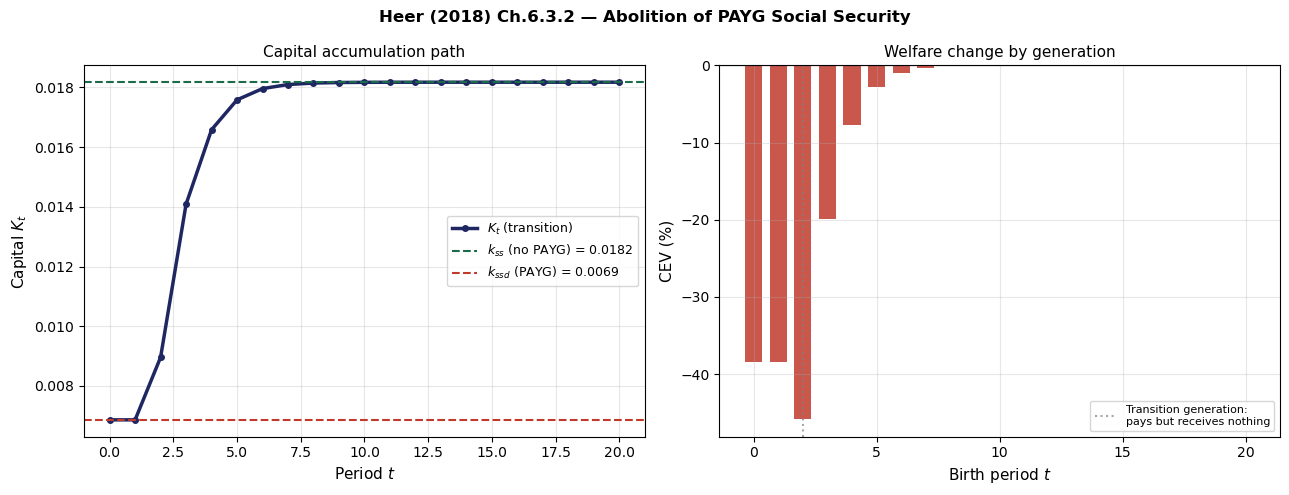

Done.


In [31]:
NAVY  = '#1E2761'
RED   = '#C0392B'
GREEN = '#1A6B4A'
periods = np.arange(nt + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Heer (2018) Ch.6.3.2 — Abolition of PAYG Social Security',
             fontsize=12, fontweight='bold')

# ── Figure 1: Capital path ───────────────────────────────────────────────
ax = axes[0]
ax.plot(periods, kt, color=NAVY, lw=2.5, marker='o', markersize=4, label='$K_t$ (transition)')
ax.axhline(kss,  color=GREEN, lw=1.5, ls='--', label=f'$k_{{ss}}$ (no PAYG) = {kss:.4f}')
ax.axhline(kssd, color=RED,   lw=1.5, ls='--', label=f'$k_{{ssd}}$ (PAYG) = {kssd:.4f}')
ax.set_xlabel('Period $t$', fontsize=11)
ax.set_ylabel('Capital $K_t$', fontsize=11)
ax.set_title('Capital accumulation path', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Figure 2: Welfare CEV ────────────────────────────────────────────────
ax = axes[1]
clrs = [GREEN if v >= 0 else RED for v in cect]
ax.bar(periods, cect*100, color=clrs, alpha=0.85, width=0.7)
ax.axhline(0, color='k', lw=0.8)
ax.axvline(2, color='grey', ls=':', alpha=0.7,
           label='Transition generation:\npays but receives nothing')
ax.set_xlabel('Birth period $t$', fontsize=11)
ax.set_ylabel('CEV (%)', fontsize=11)
ax.set_title('Welfare change by generation', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Done.')